# Hand Gesture Recognition
## using CNN + OpenCV

In [21]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Required Libraries Imported")

Required Libraries Imported


In [22]:
# Random Seed
np.random.seed(42)
tf.random.set_seed(42)

In [25]:
# Define Dataset Path
dataset_path = r"C:\Users\admin\Desktop\SkillCraft Internship\TASK - 4\Hand Gesture Recognition\Hand dataset"


In [33]:
IMG_SIZE = 64

X = []
y = []

In [34]:
print("Loading dataset...")

gesture_names = os.listdir(dataset_path)

for gesture_folder in gesture_names:

    folder_path = os.path.join(dataset_path, gesture_folder)

    if not os.path.isdir(folder_path):
        continue

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        X.append(image)
        y.append(gesture_folder)

Loading dataset...


In [35]:
# Convert to NumPy
X = np.array(images)
y = np.array(labels)

print("Image Shape:", X.shape)
print("Label Shape:", y.shape)

Image Shape: (20000, 64, 64, 3)
Label Shape: (20000,)


In [36]:
# Normalize Images
X = X / 255.0

In [37]:
# Encoding Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)


print("\nHand Gestures Used:")
for gesture in label_encoder.classes_:
    print("-", gesture)



Hand Gestures Used:
- 01_palm
- 02_l
- 03_fist
- 04_fist_moved
- 05_thumb
- 06_index
- 07_ok
- 08_palm_moved
- 09_c
- 10_down


In [38]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X,y_categorical,test_size=0.2,random_state=42,stratify=y_encoded)
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (16000, 64, 64, 3)
Testing Data Shape: (4000, 64, 64, 3)


In [39]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [40]:
# Build CNN model
model = Sequential()

# First CNN Layer
model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
)

model.add(MaxPooling2D(pool_size=(2, 2)))

# Second CNN Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third CNN Layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(len(label_encoder.classes_), activation='softmax'))



C:\anaconda\envs\ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_hand_gesture_model.keras",
    save_best_only=True
)

In [43]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Train Model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint])


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 107s 201ms/step - accuracy: 0.5245 - loss: 1.3191 - val_accuracy: 0.9660 - val_loss: 0.1991
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 196ms/step - accuracy: 0.8484 - loss: 0.4472 - val_accuracy: 0.9787 - val_loss: 0.0853
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.9025 - loss: 0.2883 - val_accuracy: 0.9610 - val_loss: 0.1235
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 176ms/step - accuracy: 0.9349 - loss: 0.2041 - val_accuracy: 0.9785 - val_loss: 0.0762
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 90s 180ms/step - accuracy: 0.9508 - loss: 0.1557 - val_accuracy: 0.9895 - val_loss: 0.0360
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 177ms/step - accuracy: 0.9597 - loss: 0.1275 - val_accuracy: 0.9858 - val_loss: 0.0529
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 93s 186ms/step - accuracy: 0.9671 - loss: 0.1083 - val_accuracy: 0.9388 - val_loss: 0.2100
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 89s 178ms/step - accuracy: 0.9660 - loss: 

In [47]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy : {accuracy * 100:.2f}%")


125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9998 - loss: 0.0022

Test Accuracy : 99.98%


In [48]:
# Predictions
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step


In [49]:
# Classification Report
print("\nClassification Report:\n")

print(classification_report(y_true,y_pred_classes,target_names=label_encoder.classes_))


Classification Report:

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [50]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[400   0   0   0   0   0   0   0   0   0]
 [  0 400   0   0   0   0   0   0   0   0]
 [  0   0 400   0   0   0   0   0   0   0]
 [  0   0   0 400   0   0   0   0   0   0]
 [  0   0   0   0 400   0   0   0   0   0]
 [  0   0   0   0   0 400   0   0   0   0]
 [  0   0   0   0   0   0 400   0   0   0]
 [  0   0   0   0   0   0   0 400   0   0]
 [  0   0   0   0   0   0   1   0 399   0]
 [  0   0   0   0   0   0   0   0   0 400]]


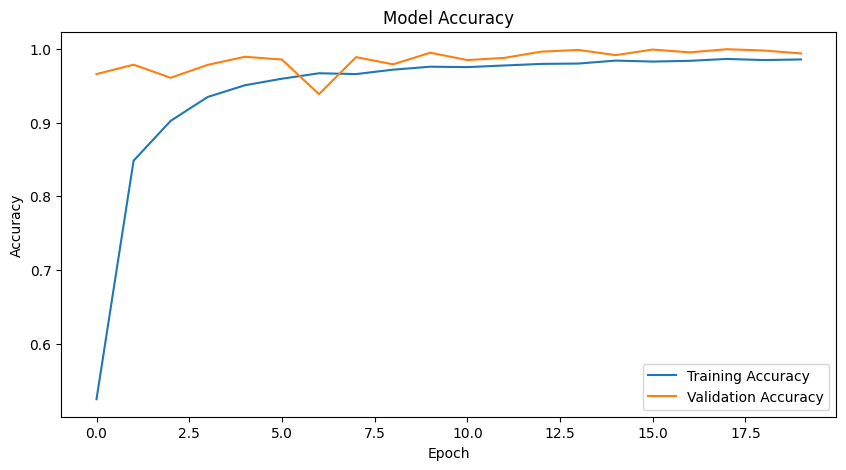

In [51]:
# Accuracy Graph
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

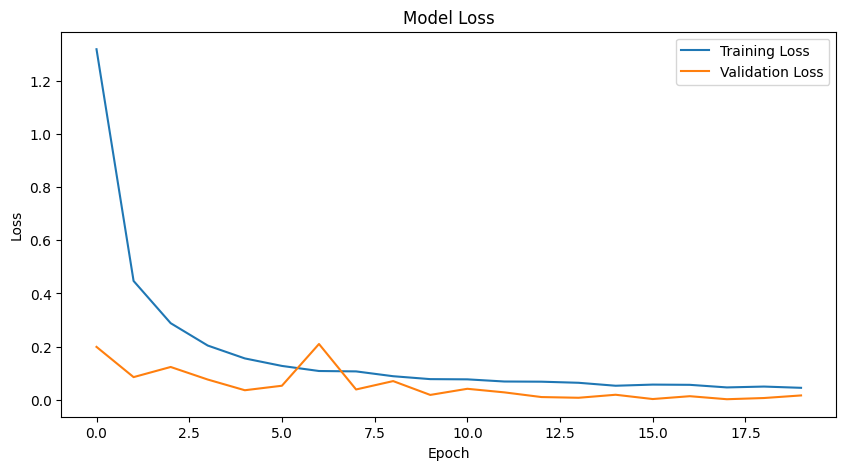

In [52]:
# Loss Graph
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [53]:
# Save Model
model.save("hand_gesture_model.keras")

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [54]:
# Real-time Hand Gesture Prediction
cap = cv2.VideoCapture(0)

print("\nPress 'Q' to quit webcam.")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Flip frame
    frame = cv2.flip(frame, 1)

    # Resize for prediction
    roi = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

    # Convert color
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    # Normalize
    roi_rgb = roi_rgb / 255.0

    # Reshape
    roi_rgb = np.expand_dims(roi_rgb, axis=0)

    # Predict
    prediction = model.predict(roi_rgb, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    label = label_encoder.inverse_transform([predicted_class])[0]

    # Display label
    text = f"{label} ({confidence*100:.2f}%)"

    cv2.putText(frame,text,(20, 40),cv2.FONT_HERSHEY_SIMPLEX,1,(0, 255, 0),2)

    cv2.imshow("Hand Gesture Recognition", frame)

    # Quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Press 'Q' to quit webcam.
